In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from openpyxl import Workbook
from openpyxl.utils.dataframe import dataframe_to_rows
from openpyxl.drawing.image import Image
import os

In [3]:
work_dir = '/content/drive/MyDrive/Estudos/Mestrado/Métodos_estatísticos/LE2_Métodos_estatísticos'
input_csv = work_dir + '/servico_publico_dados_corrigido.csv'
output_excel = work_dir + '/questao_17/questao_17_le2.xlsx'

os.makedirs(work_dir + '/questao_17', exist_ok=True)
os.chdir(work_dir + '/questao_17')

In [4]:
# Workbook novo
wb = Workbook()
# remover aba padrão
wb.remove(wb.active)

In [5]:
df = pd.read_csv(input_csv)
df.head()

,Região,Área,Ocupação,Opinião,Renda,Idade
0,Dalmácia,Educação,Funcionário público,Indiferente,1.89,29
1,Dalmácia,Infraestrutura,Assalariado/Autônomo,Indiferente,1.63,46
2,Catamarca,Educação,Funcionário público,Insatisfatório,4.50,37
3,Nortúmbria,Infraestrutura,Aposentado,Excelente,1.17,18
4,Querétaro,Infraestrutura,Empresário,Indiferente,2.84,38


## **Questão 17** - Caso houvesse dados com os perfis abaixo, como seria a opinião sobre o serviço público federal Pindorama de acordo com os dados. JUSTIFIQUEM!


In [6]:
# Função auxiliar: exibe counts e percentuais e plota
def analisa_perfil(caso, df_filtrado, titulo):
    # Tabela
    cont = df_filtrado['Opinião'].value_counts().sort_index()
    perc = (cont / cont.sum() * 100).round(1)
    print(f'=== {titulo} ===')
    df_caso = pd.DataFrame({
        'Contagem': cont,
        '%': perc
    })
    display(df_caso)

    # cria aba e escreve tabela
    ws = wb.create_sheet(title=caso)
    for r in dataframe_to_rows(df_caso, index=True, header=True):
        ws.append(r)

    # Gráfico
    fig, ax = plt.subplots(figsize=(6,4))
    perc.plot(kind='bar', ax=ax)
    ax.set_title(titulo)
    ax.set_ylabel('Percentual (%)')
    ax.set_xlabel('Opinião')
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1f}%',
                    (p.get_x()+p.get_width()/2, p.get_height()),
                    ha='center', va='bottom', fontsize=9)
    plt.tight_layout()

    plt.savefig(caso, dpi=150, bbox_inches='tight')
    img_name = f'{caso}.png'
    img_file = Image(img_name)
    img_file.anchor = 'A10'
    ws.add_image(img_file)

    plt.show()


### **a)** Região: Aquitânia; Ocupação: Assalariado/Autônomo; Renda: até 3 salários mínimos.

=== a) Aquitânia | Assalariado/Autônomo | Renda ≤ 3 SM ===


,Contagem,%
Opinião,,
Insatisfatório,5,19.2
Péssimo,21,80.8


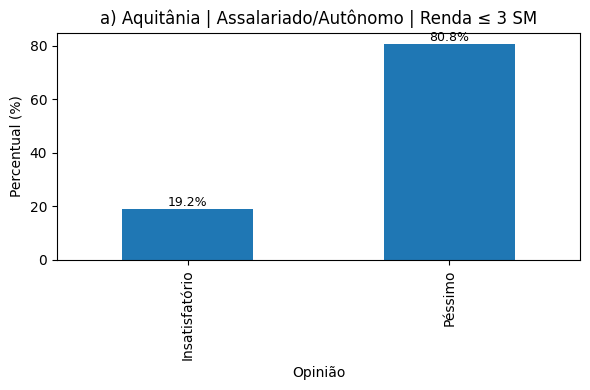

In [7]:
filtro_a = (
    (df['Região'] == 'Aquitânia') &
    (df['Ocupação'] == 'Assalariado/Autônomo') &
    (df['Renda'] <= 3)
)
analisa_perfil("caso_a",
               df[filtro_a],
               'a) Aquitânia | Assalariado/Autônomo | Renda ≤ 3 SM')

Resposta: A grande maioria das pessoas de Aquitânia, que são Assalariados/Autônomos e possui renda de até 3 salários mínimos acreditam que o serviço público federal em Pinderama é Péssimo

### **b)** Área: Infraestrutura; Ocupação: Desempregado; Idade: menos de 30 anos.

=== b) Infraestrutura | Desempregado | Idade < 30 ===


,Contagem,%
Opinião,,
Excelente,213,77.7
Indiferente,17,6.2
Satisfatório,44,16.1


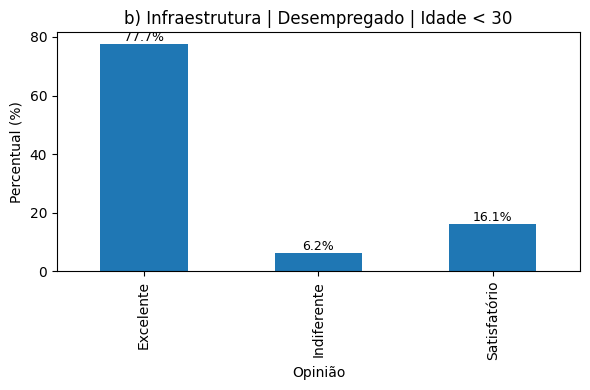

In [8]:
filtro_b = (
    (df['Área'] == 'Infraestrutura') &
    (df['Ocupação'] == 'Desempregado') &
    (df['Idade'] < 30)
)
analisa_perfil("caso_b",
               df[filtro_b],
               'b) Infraestrutura | Desempregado | Idade < 30')

Resposta: a grande maioria das pessoas desempregas, com menos de 30 anos e que consideram Infraestrutura como a área mais importante para o bem-estar da população em Pindorama acreditam que o serviço público federal é Excelente

### **c)** Ocupação: Profissional liberal ou Empresário; Renda: maior do que 3 salários mínimos; Idade: pelo menos 40 anos.

=== c) Profissional liberal/Empresário | Renda > 3 SM | Idade ≥ 40 ===


,Contagem,%
Opinião,,
Indiferente,2,0.2
Insatisfatório,26,2.6
Péssimo,990,97.2


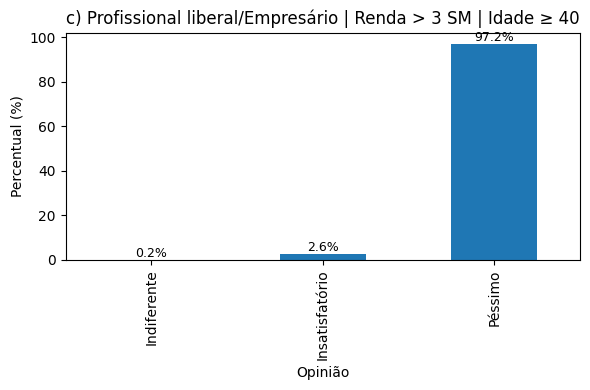

In [9]:
filtro_c = (
    df['Ocupação'].isin(['Profissional liberal', 'Empresário']) &
    (df['Renda'] > 3) &
    (df['Idade'] >= 40)
)
analisa_perfil("caso_c",
               df[filtro_c],
               'c) Profissional liberal/Empresário | Renda > 3 SM | Idade ≥ 40')

Resposta: A grande maioria das pessoas que possuem ocupação Profissional Liberal ou Empresário, tem uma tenda maior que 3 sálarios mínimos e possuem pelo menos 40 anos de idade acreditam que o serviço público federal de Pindorama é Péssimo.

In [10]:
wb.save(output_excel)